c = 0.012041882222222217
S0 = 0.02408376444444441
S1 = -0.0022879410092321363
S2 = 0.001616864171297387
DOLP sin corregir = 0.11632704226077531
DOLP corregido = 0.11632704226077531


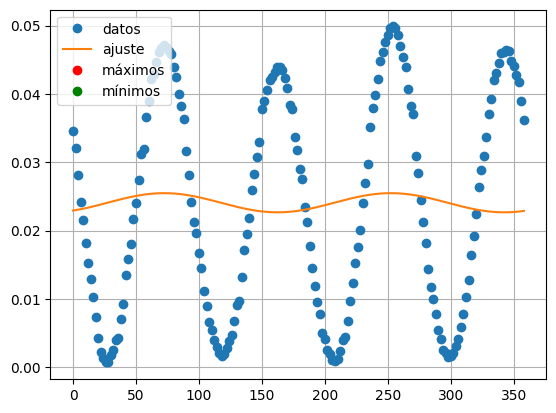

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from numpy.linalg import lstsq

import pandas as pd



medicion = pd.read_csv('Measurements/medicion_manual_v0.1.csv')
medicion['voltaje'] = medicion['voltaje'] - 0.00182
#medicion['rad'] = medicion['angulo']*np.pi/180
medicion.head()

theta=medicion['angulo']
I= medicion['voltaje']

th = np.deg2rad(theta)

A = np.column_stack([
    np.ones_like(th),
    np.ones_like(th),
    np.cos(2*th),
    np.sin(2*th)
])

p, *_ = lstsq(A, I, rcond=None)

c = p[0]
S0 = 2*p[1]
S1 = 2*p[2]
S2 = 2*p[3]

r = np.sqrt(S1**2 + S2**2)
dolp_raw = r / S0

if r > S0:
    fac = S0 / r
    S1 *= fac
    S2 *= fac

dolp = np.sqrt(S1**2 + S2**2) / S0

I_fit = c + 0.5*(S0 + S1*np.cos(2*th) + S2*np.sin(2*th))

peaks_max, _ = find_peaks(I, distance=5, prominence=0.05)
peaks_min, _ = find_peaks(-I, distance=5, prominence=0.05)

print("c =", c)
print("S0 =", S0)
print("S1 =", S1)
print("S2 =", S2)
print("DOLP sin corregir =", dolp_raw)
print("DOLP corregido =", dolp)

plt.plot(theta, I, 'o', label='datos')
plt.plot(theta, I_fit, '-', label='ajuste')
plt.plot(theta[peaks_max], I[peaks_max], 'ro', label='máximos')
plt.plot(theta[peaks_min], I[peaks_min], 'go', label='mínimos')
plt.legend()
plt.grid()
plt.show()